In [4]:
import zipfile
import os

zip_path = "/content/condition+monitoring+of+hydraulic+systems.zip"
extract_path = "/content/condition"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipping complete.")

Unzipping complete.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import VarianceThreshold
from scipy.stats import skew
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.decomposition import PCA

In [5]:
sensor_info = {
    'PS1': 6000, 'PS2': 6000, 'PS3': 6000, 'PS4': 6000, 'PS5': 6000, 'PS6': 6000,  # Pressure sensors (100 Hz)
    'EPS1': 6000,  # Motor power sensor (100 Hz)
    'FS1': 600, 'FS2': 600,  # Volume flow sensors (10 Hz)
    'TS1': 60, 'TS2': 60, 'TS3': 60, 'TS4': 60,  # Temperature sensors (1 Hz)
    'VS1': 60,  # Vibration sensor (1 Hz)
    'SE': 60,  # Efficiency factor (1 Hz)
    'CE': 60,  # Virtual cooling efficiency sensor (1 Hz)
    'CP': 60   # Virtual cooling power sensor (1 Hz)
}

file_path_template = r"../dataset/{}.txt"

data_frames = []

for sensor, num_attributes in sensor_info.items():
    file_path = file_path_template.format(sensor)

    column_names = [f"{sensor}_{i+1}" for i in range(num_attributes)]

    df_sensor = pd.read_csv(file_path, delimiter='\t', header=None, names=column_names)

    data_frames.append(df_sensor)

df_final = pd.concat(data_frames, axis=1)

print(df_final.shape)

(2205, 43680)


In [6]:
target_cols = ["cool_cond", "valve_cond", "pump_leak", "hyd_accum", "stable_flag"]
profile = pd.read_csv("../dataset/profile.txt", delimiter="\t", header=None, names=target_cols)

In [7]:
df_final = pd.concat([df_final, profile], axis=1)

## Checking Null Values

In [8]:
print(df_final.isnull().sum())

PS1_1          0
PS1_2          0
PS1_3          0
PS1_4          0
PS1_5          0
              ..
cool_cond      0
valve_cond     0
pump_leak      0
hyd_accum      0
stable_flag    0
Length: 43685, dtype: int64


## Data Visulization

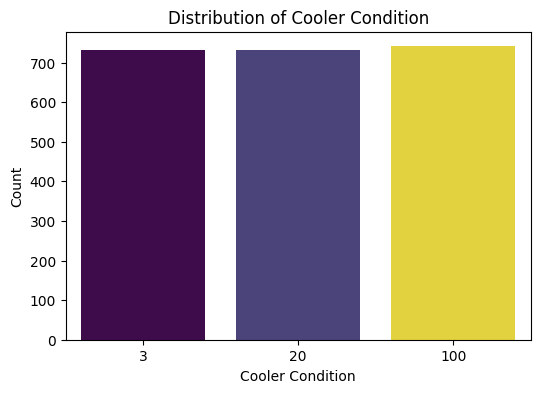

In [11]:
plt.figure(figsize=(6, 4))
x=df_final["cool_cond"]
sns.countplot(x=x, palette="viridis", hue=x, legend=False)
plt.xlabel("Cooler Condition")
plt.ylabel("Count")
plt.title("Distribution of Cooler Condition")
plt.show()

## Correlation Heatmap

In [ ]:
corr = df_final.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(12, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, cbar_kws={"shrink": .8})
plt.title("Feature Correlation Heatmap (Upper Triangular)")
plt.show()

## Sensor Data Distribution

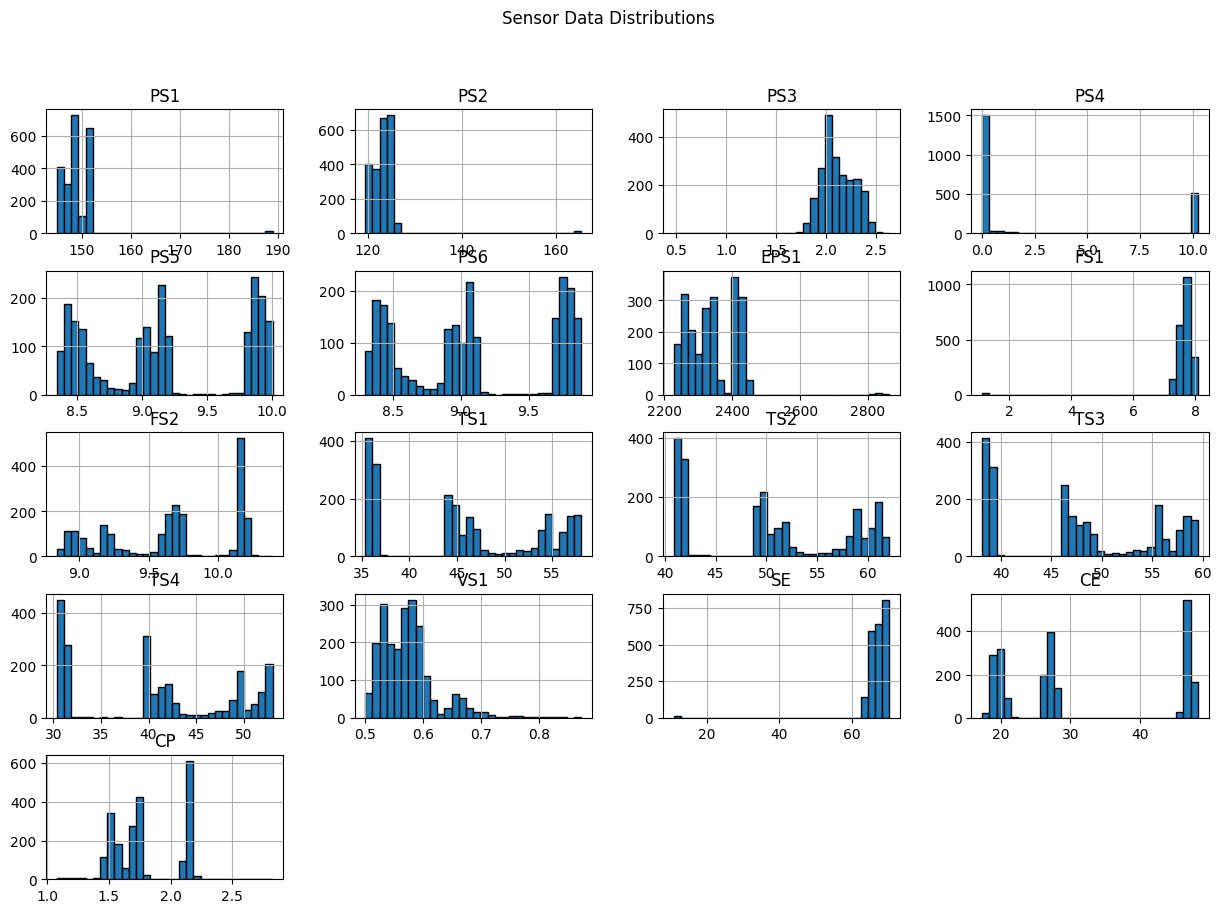

In [ ]:
df_final.drop(columns=["cool_cond"]).hist(figsize=(15, 10), bins=30, edgecolor="black")
plt.suptitle("Sensor Data Distributions")
plt.show()

##  Pair Plot for Feature Relationships

In [ ]:
sns.pairplot(df.sample(500), hue="cool_cond", diag_kind="kde", palette="coolwarm")
plt.show()

## Feature Engineering

### Remove Low-Variance Features

In [32]:
# **Feature Selection: Remove Low-Variance Features**
X = df_final.drop(columns=target_cols)
selector = VarianceThreshold(threshold=0.05)
X_selected = selector.fit_transform(X)

selected_columns = X.columns[selector.get_support()]
df_reduced = pd.DataFrame(X_selected, columns=selected_columns)

# Add target variables back
df_reduced = pd.concat([df_reduced, profile], axis=1)

print("After variance threshold:", df_reduced.shape)

After variance threshold: (2205, 39741)


## Handling Skewed Features

In [33]:
skewed_features = df_reduced.drop(columns=target_cols).apply(lambda x: skew(x)).sort_values(ascending=False)
high_skew = skewed_features[abs(skewed_features) > 1].index
df_reduced[high_skew] = np.log1p(df_reduced[high_skew])

In [34]:
scaler = StandardScaler()
df_reduced.iloc[:, :-len(target_cols)] = scaler.fit_transform(df_reduced.drop(columns=target_cols))

## Feature Selection via Mutual Information

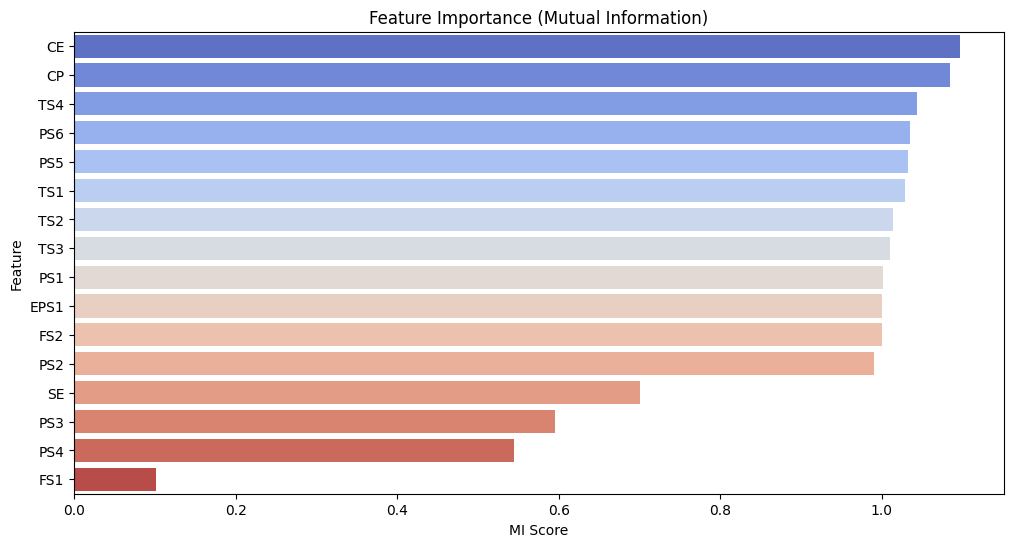

In [ ]:
mi_scores = mutual_info_classif(df_reduced.drop(columns=["cool_cond"]), df["cool_cond"])
mi_df = pd.DataFrame({"Feature": df_reduced.columns[:-1], "MI Score": mi_scores})
mi_df = mi_df.sort_values(by="MI Score", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x="MI Score", y="Feature", data=mi_df, palette="coolwarm")
plt.title("Feature Importance (Mutual Information)")
plt.show()

In [35]:
X = df_reduced.drop(columns=target_cols)
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(X_pca.shape[1])])
df_pca = pd.concat([df_pca, profile], axis=1)

print("Final dataset shape after PCA:", df_pca.shape)

Final dataset shape after PCA: (2205, 9)


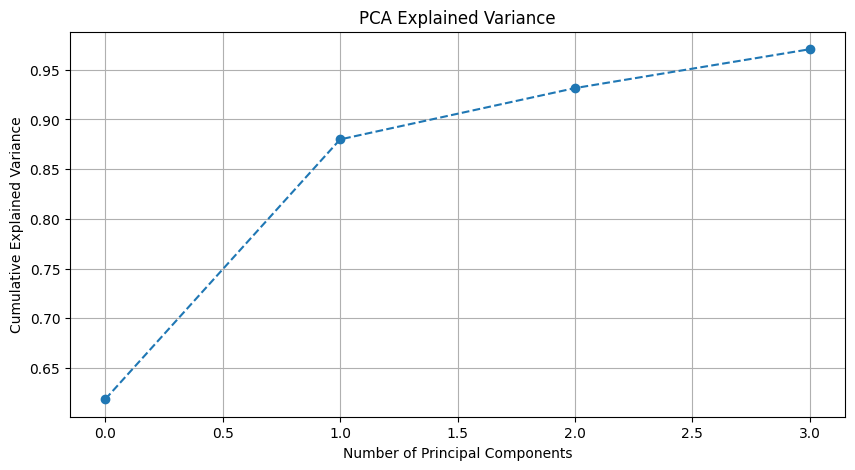

In [36]:
# **Explained Variance Plot**
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid()
plt.show()

## Training Model


Training model for cool_cond...

Accuracy for cool_cond: 0.9841

Classification Report:
               precision    recall  f1-score   support

           3       0.97      0.98      0.98       147
          20       0.99      0.97      0.98       146
         100       0.99      1.00      1.00       148

    accuracy                           0.98       441
   macro avg       0.98      0.98      0.98       441
weighted avg       0.98      0.98      0.98       441



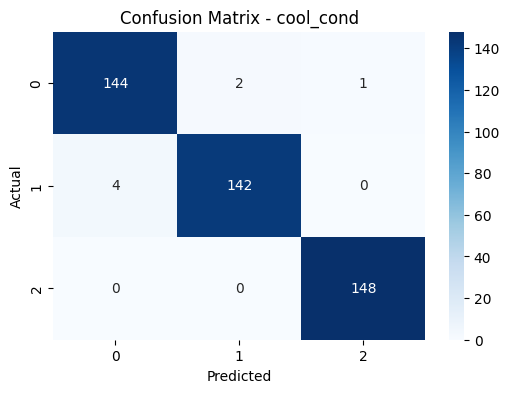


Training model for valve_cond...

Accuracy for valve_cond: 0.8526

Classification Report:
               precision    recall  f1-score   support

          73       0.89      0.89      0.89        72
          80       0.75      0.82      0.78        72
          90       0.69      0.68      0.69        72
         100       0.93      0.91      0.92       225

    accuracy                           0.85       441
   macro avg       0.81      0.82      0.82       441
weighted avg       0.85      0.85      0.85       441



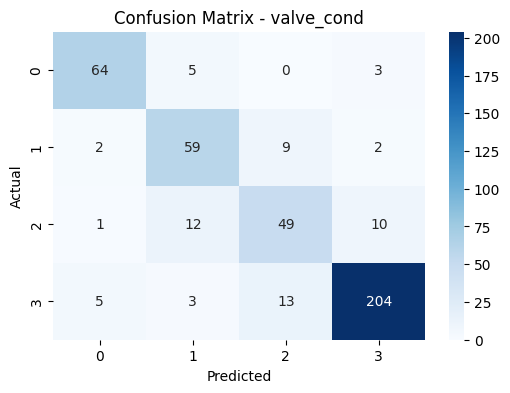


Training model for pump_leak...

Accuracy for pump_leak: 0.9615

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       244
           1       0.93      0.92      0.92        99
           2       0.94      0.94      0.94        98

    accuracy                           0.96       441
   macro avg       0.95      0.95      0.95       441
weighted avg       0.96      0.96      0.96       441



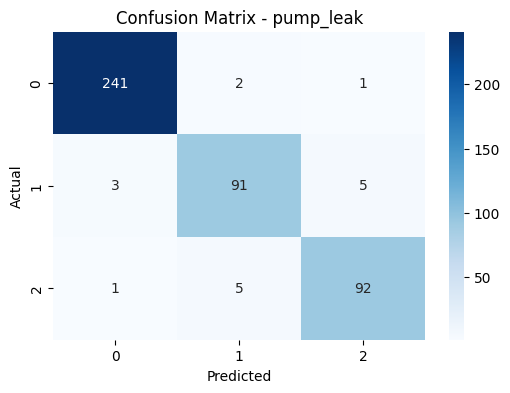


Training model for hyd_accum...

Accuracy for hyd_accum: 0.8866

Classification Report:
               precision    recall  f1-score   support

          90       0.93      0.93      0.93       161
         100       0.78      0.78      0.78        80
         115       0.84      0.80      0.82        80
         130       0.93      0.96      0.94       120

    accuracy                           0.89       441
   macro avg       0.87      0.87      0.87       441
weighted avg       0.89      0.89      0.89       441



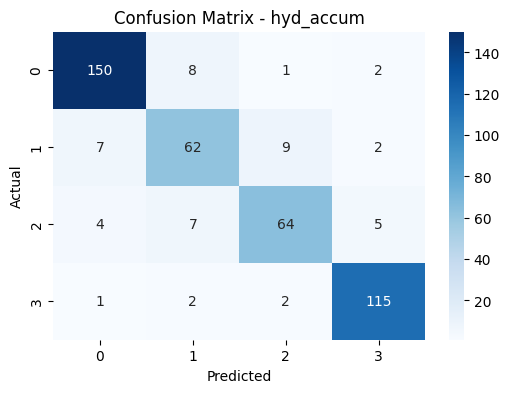


Training model for stable_flag...

Accuracy for stable_flag: 0.9683

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98       290
           1       0.97      0.94      0.95       151

    accuracy                           0.97       441
   macro avg       0.97      0.96      0.96       441
weighted avg       0.97      0.97      0.97       441



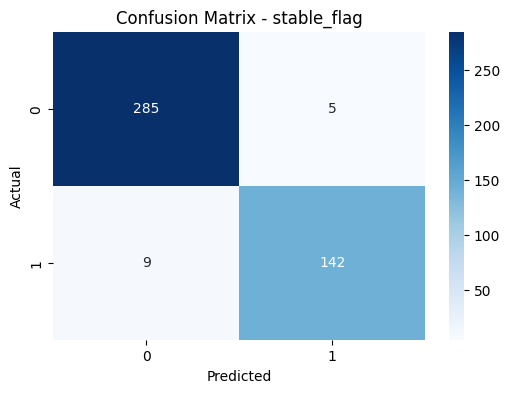


Training completed for all target variables!


In [37]:
results = {}

for target in target_cols:
    print(f"\nTraining model for {target}...\n")

    X_train, X_test, y_train, y_test = train_test_split(
        df_pca.drop(columns=target_cols), df_pca[target], test_size=0.2, random_state=42, stratify=df_pca[target]
    )

    # Train a Random Forest Model
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    # Store results
    results[target] = {
        "model": clf,
        "accuracy": accuracy_score(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }

    print(f"Accuracy for {target}: {results[target]['accuracy']:.4f}")
    print("\nClassification Report:\n", results[target]["classification_report"])

    # **Confusion Matrix Plot**
    plt.figure(figsize=(6, 4))
    sns.heatmap(results[target]["confusion_matrix"], annot=True, fmt='d', cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {target}")
    plt.show()

print("\nTraining completed for all target variables!")

## Without PCA


Training model for cool_cond...

Accuracy for cool_cond: 1.0000

Classification Report:
               precision    recall  f1-score   support

           3       1.00      1.00      1.00       147
          20       1.00      1.00      1.00       146
         100       1.00      1.00      1.00       148

    accuracy                           1.00       441
   macro avg       1.00      1.00      1.00       441
weighted avg       1.00      1.00      1.00       441



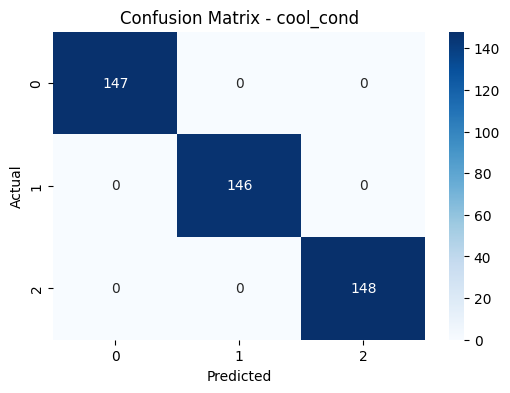


Training model for valve_cond...

Accuracy for valve_cond: 0.9977

Classification Report:
               precision    recall  f1-score   support

          73       1.00      1.00      1.00        72
          80       1.00      1.00      1.00        72
          90       1.00      0.99      0.99        72
         100       1.00      1.00      1.00       225

    accuracy                           1.00       441
   macro avg       1.00      1.00      1.00       441
weighted avg       1.00      1.00      1.00       441



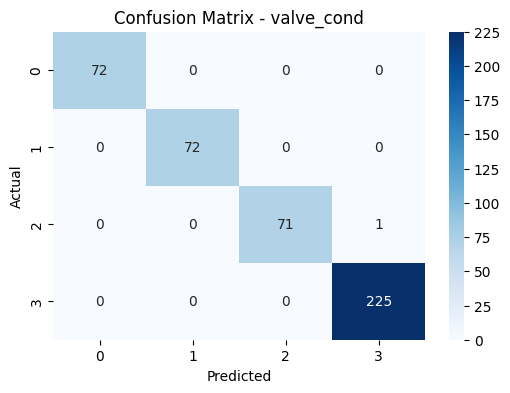


Training model for pump_leak...

Accuracy for pump_leak: 0.9955

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       244
           1       0.99      0.99      0.99        99
           2       0.99      1.00      0.99        98

    accuracy                           1.00       441
   macro avg       0.99      1.00      0.99       441
weighted avg       1.00      1.00      1.00       441



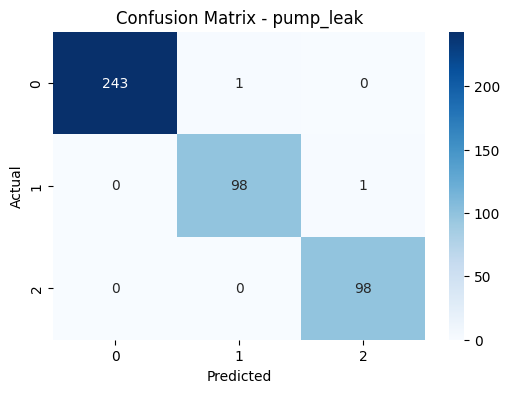


Training model for hyd_accum...

Accuracy for hyd_accum: 0.9773

Classification Report:
               precision    recall  f1-score   support

          90       0.97      1.00      0.98       161
         100       0.99      0.90      0.94        80
         115       0.95      0.99      0.97        80
         130       1.00      0.99      1.00       120

    accuracy                           0.98       441
   macro avg       0.98      0.97      0.97       441
weighted avg       0.98      0.98      0.98       441



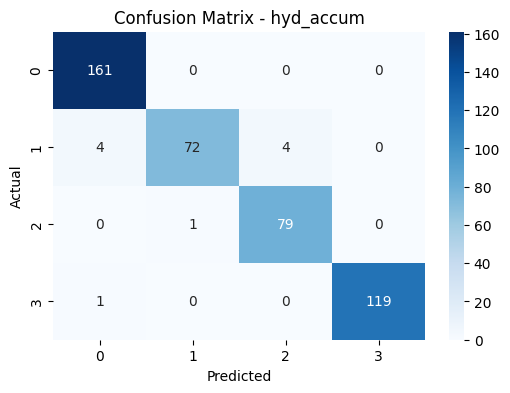


Training model for stable_flag...

Accuracy for stable_flag: 0.9683

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98       290
           1       0.97      0.94      0.95       151

    accuracy                           0.97       441
   macro avg       0.97      0.96      0.96       441
weighted avg       0.97      0.97      0.97       441



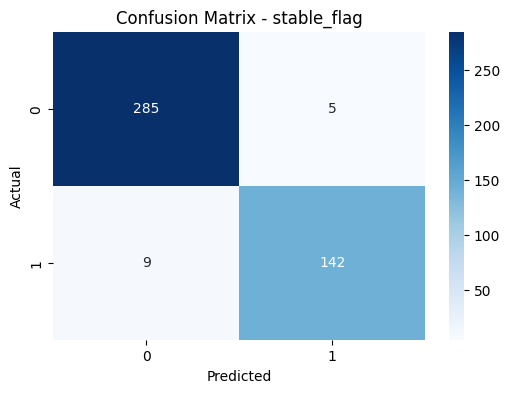


Training completed for all target variables!


In [38]:
results = {}

for target in target_cols:
    print(f"\nTraining model for {target}...\n")

    X_train, X_test, y_train, y_test = train_test_split(
        df_reduced.drop(columns=target_cols), df_reduced[target], test_size=0.2, random_state=42, stratify=df_reduced[target]
    )

    # Train a Random Forest Model
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    # Store results
    results[target] = {
        "model": clf,
        "accuracy": accuracy_score(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }

    print(f"Accuracy for {target}: {results[target]['accuracy']:.4f}")
    print("\nClassification Report:\n", results[target]["classification_report"])

    # **Confusion Matrix Plot**
    plt.figure(figsize=(6, 4))
    sns.heatmap(results[target]["confusion_matrix"], annot=True, fmt='d', cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {target}")
    plt.show()

print("\nTraining completed for all target variables!")

In [ ]:
results = {}

for target in target_cols:
    print(f"\nTraining model for {target}...\n")

    X_train, X_test, y_train, y_test = train_test_split(
        df_reduced.drop(columns=target_cols), df_reduced[target], test_size=0.2, random_state=42, stratify=df_reduced[target]
    )

    # Train a Random Forest Model
    clf = GradientBoostingClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    # Store results
    results[target] = {
        "model": clf,
        "accuracy": accuracy_score(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }

    print(f"Accuracy for {target}: {results[target]['accuracy']:.4f}")
    print("\nClassification Report:\n", results[target]["classification_report"])

    # **Confusion Matrix Plot**
    plt.figure(figsize=(6, 4))
    sns.heatmap(results[target]["confusion_matrix"], annot=True, fmt='d', cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {target}")
    plt.show()

print("\nTraining completed for all target variables!")


Training model for cool_cond...

